## EEG Feature-Space GAN (cGAN)

This notebook implements a **Conditional Generative Adversarial Network (cGAN)** that generates synthetic EEG band-power feature vectors for MDD and healthy subjects.

Rather than generating raw EEG signals (which have variable length and require complex temporal architectures), we operate in **feature space**: each recording is already represented as an 80-dimensional vector of relative band-power values (20 channels × 4 frequency bands: delta, theta, alpha, beta).

### Why feature space?
- Raw recordings range from 46,080 to 175,616 timepoints (3.8× difference), variable length is hard for standard GANs
- Band-power features are fixed at 80 dimensions regardless of recording length
- Simpler architecture trains reliably on our small dataset (181 samples)

### Notebook structure
1. Load precomputed features
2. Normalize to [-1, 1]
3. Split by class + visualise
4. Build Generator
5. Build Discriminator
6. Training loop
7. Validate Generator output
8. Augmented classification — compare GAN augmented vs baseline


### Load Precomputed Features

Load `X.npy`, `y.npy`, `groups.npy` saved by `01_pipeline.ipynb`.
This avoids re running the slow EDF extraction (181 files, several minutes).

All imports for the entire notebook are collected here.

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
from sklearn.manifold import TSNE

def find_project_root():
    p = Path.cwd()
    for parent in [p, *p.parents]:
        if (parent / ".git").exists():
            return parent
    raise FileNotFoundError("Project root (with .git) not found")

PROJECT_ROOT  = find_project_root()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed_features"

X      = np.load(PROCESSED_DIR / "X.npy")
y      = np.load(PROCESSED_DIR / "y.npy")
groups = np.load(PROCESSED_DIR / "groups.npy", allow_pickle=True)
metadata_df = pd.read_csv(PROCESSED_DIR / "metadata.csv")

print(f"X shape      : {X.shape}   (recordings × features)")
print(f"y shape      : {y.shape}   (0 = healthy, 1 = MDD)")
print(f"groups shape : {groups.shape}")
print()
print("Class breakdown:")
print(f"  Healthy (0): {(y == 0).sum()} recordings from {len(set(groups[y == 0]))} patients")
print(f"  MDD     (1): {(y == 1).sum()} recordings from {len(set(groups[y == 1]))} patients")

X shape      : (181, 80)   (recordings × features)
y shape      : (181,)   (0 = healthy, 1 = MDD)
groups shape : (181,)

Class breakdown:
  Healthy (0): 86 recordings from 30 patients
  MDD     (1): 95 recordings from 34 patients



### Normalize Features to [-1, 1]

The Generator's output layer uses Tanh, which outputs values in [-1, 1].
The real data must be in the same range so the Generator and real samples are on the same scale.

`MinMaxScaler(feature_range=(-1, 1))` is used instead of `StandardScaler` because:
- `StandardScaler` has no hard bounds, values can exceed [-1, 1]
- `MinMaxScaler` guarantees every feature is exactly in [-1, 1]

> **Note:** The scaler is fit on all 181 samples here for exploration.
> Inside the cross-validation loop (Step 8), it is fit on training data only.

In [71]:
scaler   = MinMaxScaler(feature_range=(-1, 1))
X_scaled = scaler.fit_transform(X)

print("Before scaling:")
print(f"  min={X.min():.4f}  max={X.max():.4f}  mean={X.mean():.4f}")
print("After scaling:")
print(f"  min={X_scaled.min():.4f}  max={X_scaled.max():.4f}  mean={X_scaled.mean():.4f}")
print(f"  shape: {X_scaled.shape}")

Before scaling:
  min=0.0001  max=0.2454  mean=0.0538
After scaling:
  min=-1.0000  max=1.0000  mean=-0.3478
  shape: (181, 80)


### Step 3 — Split by Class + Visualise

Separate `X_scaled` into healthy and MDD groups.
The plot shows the mean band-power profile per class per electrode which is the distribution the GAN must learn to replicate.

Healthy recordings : 86
MDD recordings     : 95


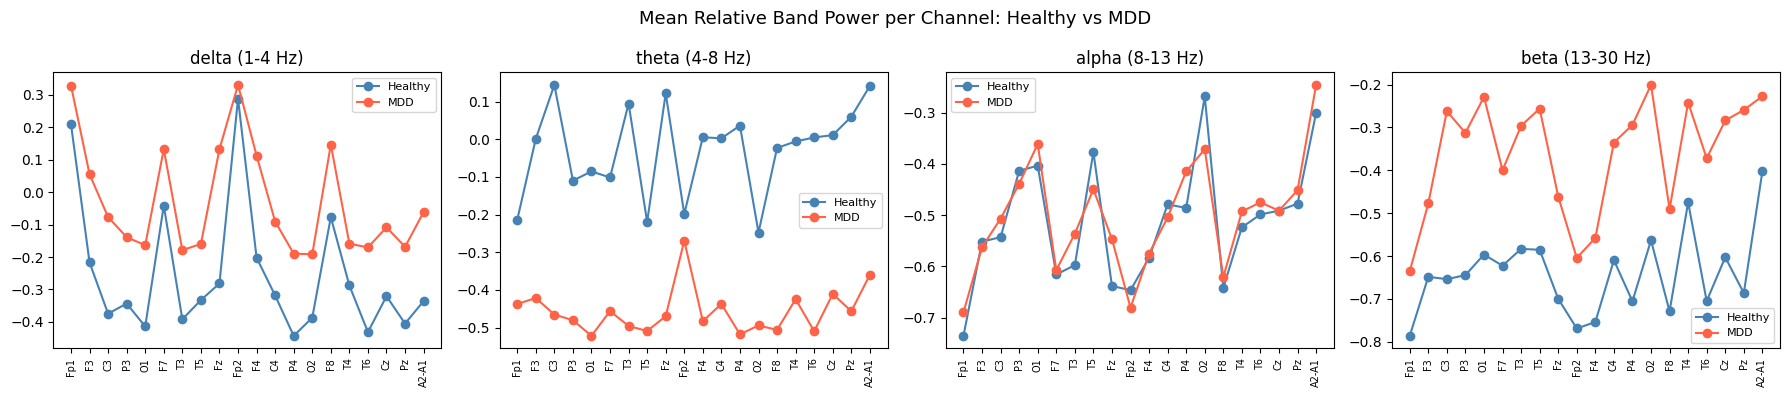

In [72]:
X_healthy = X_scaled[y == 0]
X_mdd     = X_scaled[y == 1]

print(f"Healthy recordings : {len(X_healthy)}")
print(f"MDD recordings     : {len(X_mdd)}")

band_names    = ['delta (1-4 Hz)', 'theta (4-8 Hz)', 'alpha (8-13 Hz)', 'beta (13-30 Hz)']
channel_names = ['Fp1','F3','C3','P3','O1','F7','T3','T5','Fz',
                 'Fp2','F4','C4','P4','O2','F8','T4','T6','Cz','Pz','A2-A1']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("Mean Relative Band Power per Channel: Healthy vs MDD", fontsize=13)

for b, (ax, band) in enumerate(zip(axes, band_names)):
    healthy_band = X_healthy[:, b::4].mean(axis=0)
    mdd_band     = X_mdd[:, b::4].mean(axis=0)
    x = range(len(channel_names))
    ax.plot(x, healthy_band, marker='o', label='Healthy', color='steelblue')
    ax.plot(x, mdd_band,     marker='o', label='MDD',     color='tomato')
    ax.set_title(band)
    ax.set_xticks(list(x))
    ax.set_xticklabels(channel_names, rotation=90, fontsize=7)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Step 4 — Build the Generator

The Generator takes **random noise + a class label** and outputs a synthetic 80-dim EEG feature vector.

```
noise (32-dim)  ──┐
                  ├─► Linear(34→128) → LeakyReLU
label (2-dim)   ──┘       ↓
                    Linear(128→256) → BatchNorm → LeakyReLU
                          ↓
                    Linear(256→80)  → Tanh
                          ↓
               fake 80-dim EEG vector
```

**Key design choices:**
- `LeakyReLU(0.2)`: allows small negative gradients, prevents dying neurons
- `BatchNorm1d`: stabilises training by normalising layer inputs
- `Tanh` output ensures generated values stay in [-1, 1], matching the scaled real data
- Class label is concatenated to the noise so the Generator learns **class-conditional** distributions

In [73]:
NOISE_DIM   = 32
N_CLASSES   = 2
FEATURE_DIM = 80

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            # input: noise (32) + one-hot label (2) = 34
            nn.Linear(NOISE_DIM + N_CLASSES, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, FEATURE_DIM),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        x = torch.cat([noise, labels], dim=1)  # concatenate noise + label
        return self.model(x)


# Quick sanity check
G_test = Generator()
test_noise  = torch.randn(4, NOISE_DIM)
test_labels = torch.zeros(4, N_CLASSES)
test_labels[:, 1] = 1  # MDD label
test_out = G_test(test_noise, test_labels)
print(f"Generator output shape : {test_out.shape}   (batch=4, features=80)")
print(f"Output range           : [{test_out.min().item():.3f}, {test_out.max().item():.3f}]  (should be within [-1, 1])")

Generator output shape : torch.Size([4, 80])   (batch=4, features=80)
Output range           : [-0.910, 0.858]  (should be within [-1, 1])


### Build the Critic (WGAN-GP)

WGAN-GP replaces the Discriminator (binary real/fake classifier) with a **Critic** that outputs an
unbounded real-valued score. A higher score means "more real-looking."

```
feature (80-dim) ──┐
                   ├─► Linear(82→256) → LeakyReLU → Dropout(0.3)
label (2-dim)    ──┘         ↓
                       Linear(256→128) → LeakyReLU → Dropout(0.3)
                             ↓
                       Linear(128→1)   [no Sigmoid]
                             ↓
                    raw score (higher = more real)
```

Why WGAN-GP over BCE-GAN?

| BCE-GAN | WGAN-GP |
|---------|---------|
| Binary loss saturates when D is confident → G gets no gradient | Wasserstein distance never saturates → G always gets useful signal |
| Equilibrium is fragile; easy to collapse toward class centroid | Critic feedback spreads generation across full class support |
| Gradient penalty not needed | Gradient penalty enforces 1-Lipschitz constraint on Critic |

The **gradient penalty** adds a term `λ · (‖∇C(x̂)‖₂ − 1)²` evaluated at interpolated points
between real and fake samples. This replaces weight clipping (original WGAN) with a softer constraint.

In [59]:
class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            # input: feature vector (80) + one-hot label (2) = 82
            nn.Linear(FEATURE_DIM + N_CLASSES, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(128, 1)   # no Sigmoid — raw unbounded score
        )

    def forward(self, features, labels):
        x = torch.cat([features, labels], dim=1)
        return self.model(x)


def compute_gradient_penalty(C, real, fake, labels, device="cpu"):
    """Gradient penalty: penalise Critic gradients whose L2 norm deviates from 1."""
    alpha         = torch.rand(real.size(0), 1, device=device)
    interpolated  = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    c_interp      = C(interpolated, labels)

    gradients = torch.autograd.grad(
        outputs=c_interp,
        inputs=interpolated,
        grad_outputs=torch.ones_like(c_interp),
        create_graph=True,
        retain_graph=True,
    )[0]
    return ((gradients.norm(2, dim=1) - 1) ** 2).mean()


# Sanity check
C_test   = Critic()
test_out = C_test(test_features, test_labels)
print(f"Critic output shape : {test_out.shape}   (batch=4, 1 raw score each)")
print(f"Output range        : [{test_out.min().item():.3f}, {test_out.max().item():.3f}]  (unbounded — no Sigmoid)")

Critic output shape : torch.Size([4, 1])   (batch=4, 1 raw score each)
Output range        : [-0.089, 0.213]  (unbounded — no Sigmoid)


### WGAN-GP Training Loop

Training alternates between **Critic updates** (5× per Generator step) and **Generator updates**:

**Critic step (×5):**
```
loss_C = −E[C(real)] + E[C(fake)] + λ · gradient_penalty
```
- Maximise score for real, minimise for fake → Wasserstein distance estimate
- Gradient penalty keeps Critic 1-Lipschitz so the distance estimate is valid

**Generator step (×1):**
```
loss_G = −E[C(G(z, label))]
```
- G wants to produce samples the Critic scores *high* (more real-looking)

**Key differences from BCE-GAN:**
- No Sigmoid / no BCELoss — Critic outputs a raw score
- 5 Critic updates per Generator step (standard WGAN ratio) — ensures Critic stays ahead
- Adam with `betas=(0, 0.9)` — no momentum on first moment (recommended for WGAN-GP)
- `LAMBDA_GP = 10` — gradient penalty weight (standard value from original paper)

In [74]:
LAMBDA_GP = 10   # gradient penalty coefficient (standard WGAN-GP value)
N_CRITIC  = 5    # critic steps per generator step

def train_wgan_gp(X_train, y_train, epochs=1500, batch_size=32, lr=1e-4, verbose=True):
    """
    Train a conditional WGAN-GP on X_train (already scaled to [-1, 1]).
    Returns the trained Generator and per-epoch losses.
    """
    G = Generator()
    C = Critic()

    # betas=(0, 0.9) is standard for WGAN-GP — no first-moment momentum
    opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0, 0.9))
    opt_C = torch.optim.Adam(C.parameters(), lr=lr, betas=(0, 0.9))

    X_tensor = torch.FloatTensor(X_train)
    y_tensor = torch.LongTensor(y_train.astype(int))

    y_onehot = torch.zeros(len(y_train), N_CLASSES)
    y_onehot.scatter_(1, y_tensor.unsqueeze(1), 1)

    n = len(X_tensor)
    g_losses, c_losses = [], []

    for epoch in range(epochs):
        c_loss_accum = 0.0
        for _ in range(N_CRITIC):
            idx           = torch.randint(0, n, (batch_size,))
            real_features = X_tensor[idx]
            real_labels   = y_onehot[idx]

            noise         = torch.randn(batch_size, NOISE_DIM)
            fake_features = G(noise, real_labels).detach()

            gp     = compute_gradient_penalty(C, real_features, fake_features, real_labels)
            c_real = C(real_features, real_labels).mean()
            c_fake = C(fake_features, real_labels).mean()

            # Wasserstein distance: maximise C(real) − C(fake), plus GP
            loss_C = -c_real + c_fake + LAMBDA_GP * gp

            opt_C.zero_grad()
            loss_C.backward()
            opt_C.step()
            c_loss_accum += loss_C.item()

        idx         = torch.randint(0, n, (batch_size,))
        real_labels = y_onehot[idx]

        noise         = torch.randn(batch_size, NOISE_DIM)
        fake_features = G(noise, real_labels)

        # G wants Critic to score fake samples high
        loss_G = -C(fake_features, real_labels).mean()

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

        g_losses.append(loss_G.item())
        c_losses.append(c_loss_accum / N_CRITIC)

        if verbose and (epoch + 1) % 200 == 0:
            print(f"Epoch {epoch+1:4d}/{epochs}  |  "
                  f"loss_C: {c_losses[-1]:.4f}  |  loss_G: {g_losses[-1]:.4f}")

    return G, g_losses, c_losses


# Train on full dataset for exploration
print("Training WGAN-GP on full dataset for validation...")
G, g_losses, c_losses = train_wgan_gp(X_scaled, y, epochs=1500)

Training WGAN-GP on full dataset for validation...
Epoch  200/1500  |  loss_C: -0.5565  |  loss_G: -0.3874
Epoch  400/1500  |  loss_C: -0.4186  |  loss_G: 0.8903
Epoch  600/1500  |  loss_C: -0.3963  |  loss_G: 0.7908
Epoch  800/1500  |  loss_C: -0.3662  |  loss_G: 1.2724
Epoch 1000/1500  |  loss_C: -0.4300  |  loss_G: 0.8162
Epoch 1200/1500  |  loss_C: -0.3193  |  loss_G: 0.6615
Epoch 1400/1500  |  loss_C: -0.3617  |  loss_G: 0.5010


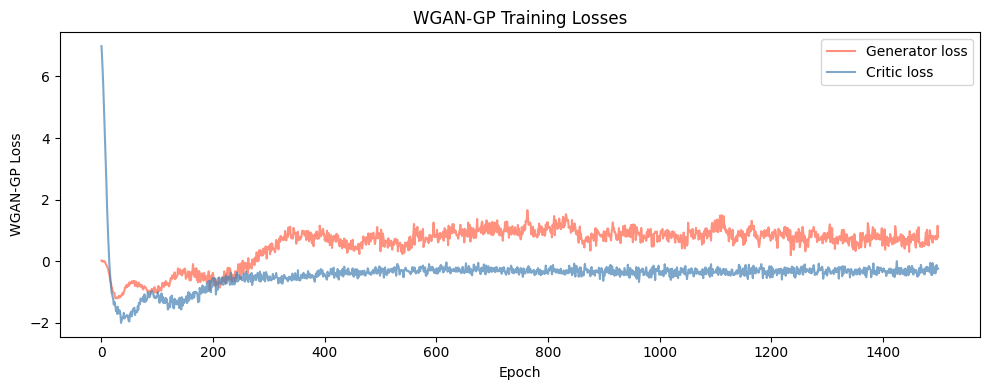

Final Critic loss   : -0.2427
Final Generator loss: 0.7814


In [75]:
# Plot training losses
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(g_losses, label='Generator loss',  color='tomato',    alpha=0.7)
ax.plot(c_losses, label='Critic loss',     color='steelblue', alpha=0.7)
ax.set_xlabel('Epoch')
ax.set_ylabel('WGAN-GP Loss')
ax.set_title('WGAN-GP Training Losses')
ax.legend()
plt.tight_layout()
plt.show()

# In WGAN-GP, loss_C ≈ −(Wasserstein distance) + GP term.
# A decreasing |loss_C| indicates the Critic is learning a tighter bound.
# loss_G should trend negative as G improves (Critic scores fakes higher).
print(f"Final Critic loss   : {c_losses[-1]:.4f}")
print(f"Final Generator loss: {g_losses[-1]:.4f}")

### Validate Generator Output

Before using synthetic samples to train a classifier, verify they are statistically similar to real data:

1. **Distribution plots**: real vs fake per band (histograms should overlap)
2. **t-SNE visualisation**: real and fake points should intermix in 2D

If fake points form a separate cluster in t-SNE, the GAN has not learned the real distribution and more training or architecture tuning is needed.

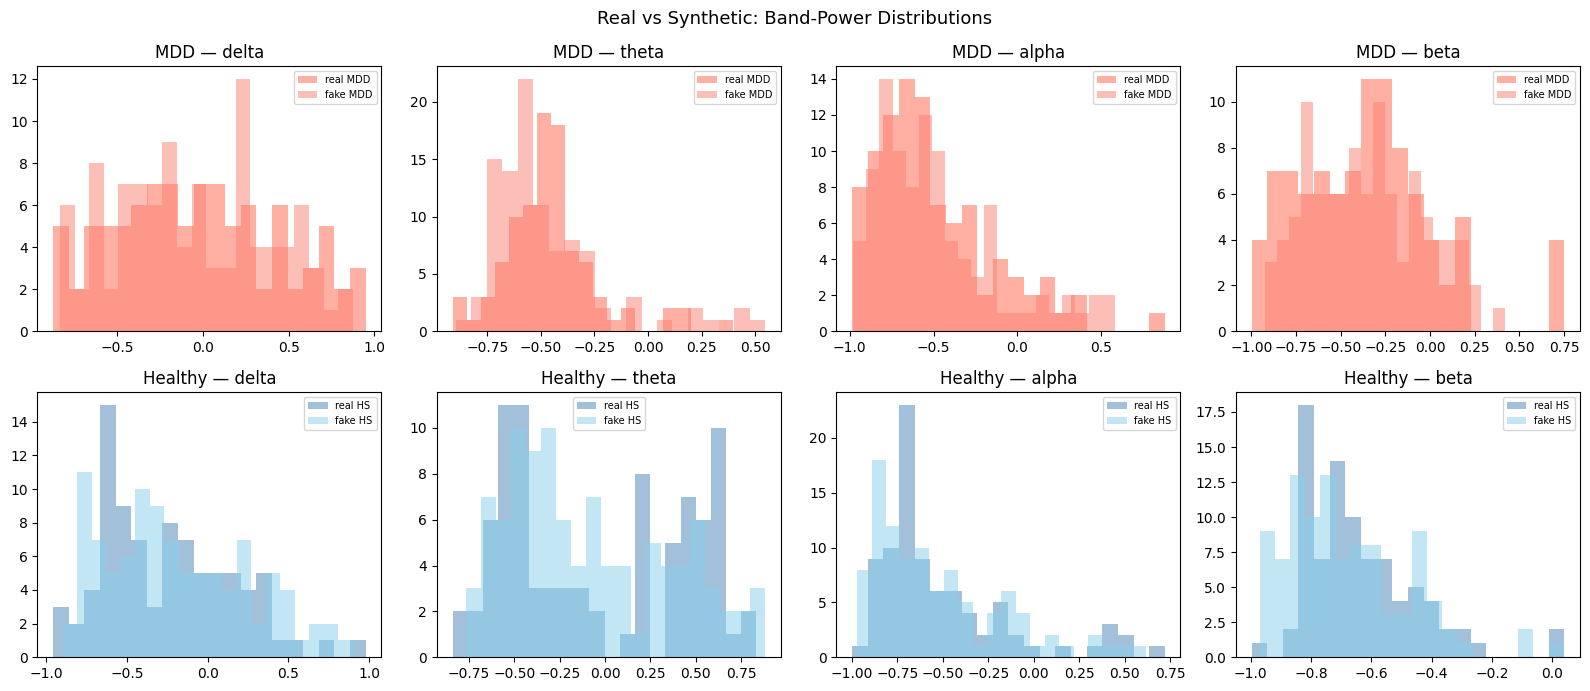

In [76]:
G.eval()
with torch.no_grad():
    # Generate 100 synthetic MDD samples
    noise_mdd = torch.randn(100, NOISE_DIM)
    label_mdd = torch.zeros(100, N_CLASSES); label_mdd[:, 1] = 1
    fake_mdd  = G(noise_mdd, label_mdd).numpy()

    # Generate 100 synthetic healthy samples
    noise_hs  = torch.randn(100, NOISE_DIM)
    label_hs  = torch.zeros(100, N_CLASSES); label_hs[:, 0] = 1
    fake_hs   = G(noise_hs, label_hs).numpy()

band_names = ['delta', 'theta', 'alpha', 'beta']
fig, axes  = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle("Real vs Synthetic: Band-Power Distributions", fontsize=13)

for b, (band, ax_mdd, ax_hs) in enumerate(zip(band_names, axes[0], axes[1])):
    real_m = X_mdd[:, b::4].mean(axis=1)
    fake_m = fake_mdd[:, b::4].mean(axis=1)
    real_h = X_healthy[:, b::4].mean(axis=1)
    fake_h = fake_hs[:, b::4].mean(axis=1)

    ax_mdd.hist(real_m, bins=20, alpha=0.5, label='real MDD',  color='tomato')
    ax_mdd.hist(fake_m, bins=20, alpha=0.5, label='fake MDD',  color='salmon')
    ax_mdd.set_title(f"MDD — {band}")
    ax_mdd.legend(fontsize=7)

    ax_hs.hist(real_h, bins=20, alpha=0.5, label='real HS',   color='steelblue')
    ax_hs.hist(fake_h, bins=20, alpha=0.5, label='fake HS',   color='skyblue')
    ax_hs.set_title(f"Healthy — {band}")
    ax_hs.legend(fontsize=7)

plt.tight_layout()
plt.show()

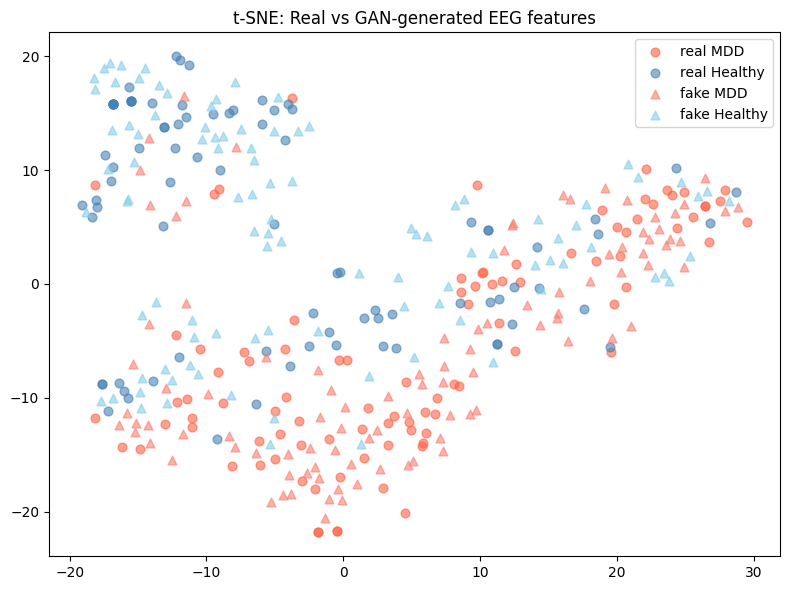

Good sign : real and fake points of the same class intermix
Bad sign  : fake points cluster separately from real ones


In [77]:
# t-SNE visualisation 
# Combine real and fake samples and project to 2D
combined = np.vstack([X_mdd, X_healthy, fake_mdd, fake_hs])
labels_vis = (
    ['real MDD']     * len(X_mdd) +
    ['real Healthy'] * len(X_healthy) +
    ['fake MDD']     * len(fake_mdd) +
    ['fake Healthy'] * len(fake_hs)
)

tsne      = TSNE(n_components=2, random_state=42, perplexity=30)
embedded  = tsne.fit_transform(combined)

colours = {'real MDD': 'tomato', 'real Healthy': 'steelblue',
           'fake MDD': 'salmon', 'fake Healthy': 'skyblue'}
markers = {'real MDD': 'o', 'real Healthy': 'o',
           'fake MDD': '^', 'fake Healthy': '^'}

fig, ax = plt.subplots(figsize=(8, 6))
for label in ['real MDD', 'real Healthy', 'fake MDD', 'fake Healthy']:
    mask = [l == label for l in labels_vis]
    ax.scatter(embedded[mask, 0], embedded[mask, 1],
               c=colours[label], marker=markers[label],
               label=label, alpha=0.6, s=40)

ax.set_title("t-SNE: Real vs GAN-generated EEG features")
ax.legend()
plt.tight_layout()
plt.show()

print("Good sign : real and fake points of the same class intermix")
print("Bad sign  : fake points cluster separately from real ones")

### Augmented Classification

The key question: **does GAN augmentation improve classification accuracy?**

The GAN must be trained **inside** the cross-validation loop, using training data only.
If the GAN is fit on all data before splitting, test patient information leaks into the synthetic samples.

```
For each GroupKFold split:
  1. Fit scaler on training patients only
  2. Train GAN on scaled training data only
  3. Generate N synthetic samples per class
  4. Train SVM on real + synthetic training data
  5. Evaluate on real test patients (no augmentation)
```

Results are compared against the baseline SVM (no augmentation) from `01_pipeline.ipynb`: **79.0% accuracy**.

In [78]:
N_POOL      = 300   # oversample pool, best N filtered down per-fold
GAN_EPOCHS  = 1500  # generator steps (critic runs 5× per step internally)

def filter_by_centroid(fake_samples, real_samples, n_keep):
    """Keep the n_keep synthetic samples with highest cosine similarity to real class centroid."""
    centroid   = real_samples.mean(axis=0)
    norms_fake = np.linalg.norm(fake_samples, axis=1, keepdims=True).clip(1e-8)
    norm_cent  = np.linalg.norm(centroid).clip(1e-8)
    sims       = (fake_samples / norms_fake) @ (centroid / norm_cent)
    top_idx    = np.argsort(sims)[::-1][:n_keep]
    return fake_samples[top_idx]

gkf = GroupKFold(n_splits=5)

baseline_results = []
gan_results      = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), start=1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Scale inside fold (fit on train only)
    fold_scaler = MinMaxScaler(feature_range=(-1, 1))
    X_train_sc  = fold_scaler.fit_transform(X_train)
    X_test_sc   = fold_scaler.transform(X_test)

    # Baseline: SVM with no augmentation
    clf_base = SVC(kernel="rbf")
    clf_base.fit(X_train_sc, y_train)
    y_pred_base = clf_base.predict(X_test_sc)
    baseline_results.append({
        "fold":     fold,
        "accuracy": accuracy_score(y_test, y_pred_base),
        "f1":       f1_score(y_test, y_pred_base)
    })

    # Train WGAN-GP on training fold only 
    print(f"Fold {fold}: training WGAN-GP ({GAN_EPOCHS} epochs)...")
    G_fold, _, _ = train_wgan_gp(X_train_sc, y_train, epochs=GAN_EPOCHS, verbose=False)
    G_fold.eval()

    # Generate large pool then quality-filter 
    with torch.no_grad():
        lbl_mdd = torch.zeros(N_POOL, N_CLASSES); lbl_mdd[:, 1] = 1
        lbl_hs  = torch.zeros(N_POOL, N_CLASSES); lbl_hs[:, 0]  = 1
        fake_mdd_pool = G_fold(torch.randn(N_POOL, NOISE_DIM), lbl_mdd).numpy()
        fake_hs_pool  = G_fold(torch.randn(N_POOL, NOISE_DIM), lbl_hs).numpy()

    # Mode collapse check
    mdd_std = fake_mdd_pool.std(axis=0).mean()
    hs_std  = fake_hs_pool.std(axis=0).mean()
    if mdd_std < 0.05 or hs_std < 0.05:
        print(f"  ⚠ Mode collapse — MDD std={mdd_std:.4f}, HS std={hs_std:.4f}")
    else:
        print(f"  ✓ No collapse  — MDD std={mdd_std:.4f}, HS std={hs_std:.4f}")

    # Proportional cap: at most 1 synthetic per 3 real
    n_mdd_keep = max(10, (y_train == 1).sum() // 3)
    n_hs_keep  = max(10, (y_train == 0).sum() // 3)

    # Quality filter: cosine similarity to real class centroid
    real_mdd_sc = X_train_sc[y_train == 1]
    real_hs_sc  = X_train_sc[y_train == 0]
    fake_mdd_fold = filter_by_centroid(fake_mdd_pool, real_mdd_sc, n_mdd_keep)
    fake_hs_fold  = filter_by_centroid(fake_hs_pool,  real_hs_sc,  n_hs_keep)

    print(f"  Keeping {n_mdd_keep} MDD + {n_hs_keep} HS synthetic "
          f"(real: {len(real_mdd_sc)} MDD, {len(real_hs_sc)} HS)")

    # Augment training set 
    X_aug = np.vstack([X_train_sc, fake_mdd_fold, fake_hs_fold])
    y_aug = np.concatenate([y_train,
                            np.ones(n_mdd_keep),
                            np.zeros(n_hs_keep)])

    # GAN augmented SVM 
    clf_gan = SVC(kernel="rbf")
    clf_gan.fit(X_aug, y_aug)
    y_pred_gan = clf_gan.predict(X_test_sc)
    gan_results.append({
        "fold":     fold,
        "accuracy": accuracy_score(y_test, y_pred_gan),
        "f1":       f1_score(y_test, y_pred_gan)
    })

    print(f"  baseline acc={baseline_results[-1]['accuracy']:.3f}  |  "
          f"GAN acc={gan_results[-1]['accuracy']:.3f}  |  "
          f"Δ={gan_results[-1]['accuracy'] - baseline_results[-1]['accuracy']:+.3f}")

Fold 1: training WGAN-GP (1500 epochs)...
  ✓ No collapse  — MDD std=0.4285, HS std=0.4153
  Keeping 25 MDD + 22 HS synthetic (real: 76 MDD, 68 HS)
  baseline acc=0.946  |  GAN acc=0.946  |  Δ=+0.000
Fold 2: training WGAN-GP (1500 epochs)...
  ✓ No collapse  — MDD std=0.4201, HS std=0.4167
  Keeping 24 MDD + 24 HS synthetic (real: 72 MDD, 72 HS)
  baseline acc=0.784  |  GAN acc=0.784  |  Δ=+0.000
Fold 3: training WGAN-GP (1500 epochs)...
  ✓ No collapse  — MDD std=0.3998, HS std=0.3707
  Keeping 26 MDD + 22 HS synthetic (real: 79 MDD, 66 HS)
  baseline acc=0.556  |  GAN acc=0.556  |  Δ=+0.000
Fold 4: training WGAN-GP (1500 epochs)...
  ✓ No collapse  — MDD std=0.4097, HS std=0.4124
  Keeping 24 MDD + 24 HS synthetic (real: 74 MDD, 72 HS)
  baseline acc=0.771  |  GAN acc=0.800  |  Δ=+0.029
Fold 5: training WGAN-GP (1500 epochs)...
  ✓ No collapse  — MDD std=0.4105, HS std=0.4132
  Keeping 26 MDD + 22 HS synthetic (real: 79 MDD, 66 HS)
  baseline acc=0.639  |  GAN acc=0.639  |  Δ=+0.000


                Model  Accuracy  F1 Score  Acc Std
Baseline SVM (no aug)  0.739121  0.778033 0.149631
    GAN-augmented SVM  0.744835  0.783029 0.151705


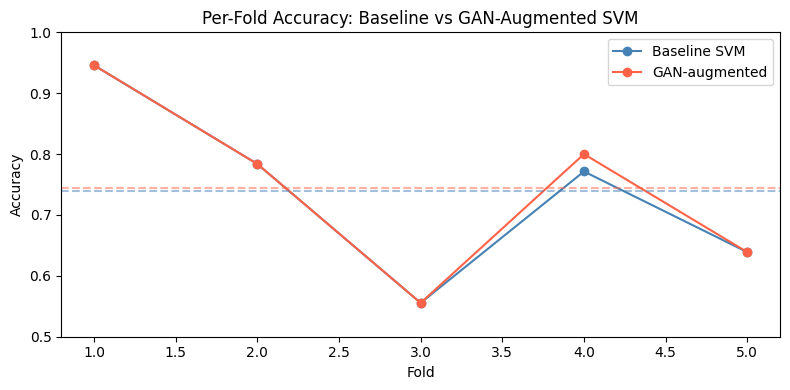

In [80]:
# Summary table 
base_df = pd.DataFrame(baseline_results)
gan_df  = pd.DataFrame(gan_results)

summary = pd.DataFrame({
    "Model":    ["Baseline SVM (no aug)", "GAN-augmented SVM"],
    "Accuracy": [base_df["accuracy"].mean(), gan_df["accuracy"].mean()],
    "F1 Score": [base_df["f1"].mean(),       gan_df["f1"].mean()],
    "Acc Std":  [base_df["accuracy"].std(),  gan_df["accuracy"].std()],
})
print(summary.to_string(index=False))

# Per fold accuracy plot
folds = base_df["fold"]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(folds, base_df["accuracy"], marker='o', label='Baseline SVM', color='steelblue')
ax.plot(folds, gan_df["accuracy"],  marker='o', label='GAN-augmented', color='tomato')
ax.axhline(base_df["accuracy"].mean(), linestyle='--', color='steelblue', alpha=0.5)
ax.axhline(gan_df["accuracy"].mean(),  linestyle='--', color='tomato',    alpha=0.5)
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.set_title('Per-Fold Accuracy: Baseline vs GAN-Augmented SVM')
ax.legend()
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

### Gaussian Noise Augmentation (Comparison Baseline)

Standard augmentation: randomly pick real training samples, add small Gaussian noise,
clip to [-1, 1] to stay in the valid range. Same proportional cap as the GAN (1 synthetic per 3 real).

This is the simplest possible augmentation, if it matches GAN performance, the dataset
is the bottleneck, not the generator architecture.

In [81]:
NOISE_SIGMA = 0.05   # Gaussian noise std (features are in [-1, 1])
rng         = np.random.default_rng(42)

gkf              = GroupKFold(n_splits=5)
noise_results    = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), start=1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    fold_scaler = MinMaxScaler(feature_range=(-1, 1))
    X_train_sc  = fold_scaler.fit_transform(X_train)
    X_test_sc   = fold_scaler.transform(X_test)

    # Proportional cap: same ratio as GAN step
    real_mdd_sc = X_train_sc[y_train == 1]
    real_hs_sc  = X_train_sc[y_train == 0]
    n_mdd = max(10, len(real_mdd_sc) // 3)
    n_hs  = max(10, len(real_hs_sc)  // 3)

    # Sample with replacement from real data, then add noise
    aug_mdd = real_mdd_sc[rng.integers(0, len(real_mdd_sc), n_mdd)] + rng.normal(0, NOISE_SIGMA, (n_mdd, FEATURE_DIM))
    aug_hs  = real_hs_sc [rng.integers(0, len(real_hs_sc),  n_hs )] + rng.normal(0, NOISE_SIGMA, (n_hs,  FEATURE_DIM))
    aug_mdd = np.clip(aug_mdd, -1, 1)
    aug_hs  = np.clip(aug_hs,  -1, 1)

    X_aug = np.vstack([X_train_sc, aug_mdd, aug_hs])
    y_aug = np.concatenate([y_train, np.ones(n_mdd), np.zeros(n_hs)])

    clf_noise = SVC(kernel="rbf")
    clf_noise.fit(X_aug, y_aug)
    y_pred = clf_noise.predict(X_test_sc)

    noise_results.append({
        "fold": fold,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1":       f1_score(y_test, y_pred)
    })
    print(f"Fold {fold}: noise acc={noise_results[-1]['accuracy']:.3f}")

noise_df = pd.DataFrame(noise_results)
print(f"\nGaussian noise  mean acc={noise_df['accuracy'].mean():.3f}  "
      f"F1={noise_df['f1'].mean():.3f}  std={noise_df['accuracy'].std():.3f}")

Fold 1: noise acc=0.919
Fold 2: noise acc=0.730
Fold 3: noise acc=0.722
Fold 4: noise acc=0.743
Fold 5: noise acc=0.667

Gaussian noise  mean acc=0.756  F1=0.779  std=0.096


### Condition-Specific WGAN-GP

Problem with the mixed-condition GAN: all three recording conditions (eyesClosed, eyesOpen, P300)
are pooled, so the GAN tries to learn MDD vs Healthy across three different EEG distributions.
Any sample it generates sits somewhere in that mixed space.

**Fix**: train a **separate WGAN-GP per condition** within each fold.
- 3 GANs per fold: eyesClosed, eyesOpen, P300
- Each GAN sees only that condition's samples (~48 per fold) and learns a clean single-condition boundary
- Synthetic samples are condition-matched before being added to training

No architecture changes needed, the same Generator/Critic work fine with per-condition subsets.

In [82]:
CONDITIONS      = ['eyesClosed', 'eyesOpen', 'P300']
COND_GAN_EPOCHS = 1000   # shorter per GAN — each sees only ~48 samples

# Align condition labels with X (metadata rows match X rows)
conditions_arr = metadata_df['condition'].values

gkf           = GroupKFold(n_splits=5)
cond_results  = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), start=1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    cond_train      = conditions_arr[train_idx]

    fold_scaler = MinMaxScaler(feature_range=(-1, 1))
    X_train_sc  = fold_scaler.fit_transform(X_train)
    X_test_sc   = fold_scaler.transform(X_test)

    # Baseline (same as Step 8 — for reference)
    clf_base = SVC(kernel="rbf")
    clf_base.fit(X_train_sc, y_train)

    # Per-condition WGAN-GP

    for cond in CONDITIONS:
        cond_mask = cond_train == cond
        X_cond    = X_train_sc[cond_mask]
        y_cond    = y_train[cond_mask]

        if len(X_cond) < 15 or len(np.unique(y_cond)) < 2:
            print(f"  Fold {fold} / {cond}: skipped (n={len(X_cond)}, classes={np.unique(y_cond)})")
            continue

        G_cond, _, _ = train_wgan_gp(X_cond, y_cond, epochs=COND_GAN_EPOCHS, verbose=False)
        G_cond.eval()

        # Proportional cap per condition-class
        n_mdd_c = max(5, (y_cond == 1).sum() // 3)
        n_hs_c  = max(5, (y_cond == 0).sum() // 3)

        with torch.no_grad():
            lbl_mdd = torch.zeros(N_POOL, N_CLASSES); lbl_mdd[:, 1] = 1
            lbl_hs  = torch.zeros(N_POOL, N_CLASSES); lbl_hs[:, 0]  = 1
            pool_mdd = G_cond(torch.randn(N_POOL, NOISE_DIM), lbl_mdd).numpy()
            pool_hs  = G_cond(torch.randn(N_POOL, NOISE_DIM), lbl_hs).numpy()

        fake_mdd = filter_by_centroid(pool_mdd, X_cond[y_cond == 1], n_mdd_c)
        fake_hs  = filter_by_centroid(pool_hs,  X_cond[y_cond == 0], n_hs_c)

        all_fake_X.append(np.vstack([fake_mdd, fake_hs]))
        all_fake_y.append(np.concatenate([np.ones(n_mdd_c), np.zeros(n_hs_c)]))
        print(f"  Fold {fold} / {cond:12s}: {n_mdd_c} MDD + {n_hs_c} HS synthetic")

    # Augment and classify
    if all_fake_X:
        X_aug = np.vstack([X_train_sc] + all_fake_X)
        y_aug = np.concatenate([y_train] + all_fake_y)
    else:
        X_aug, y_aug = X_train_sc, y_train

    clf_cond = SVC(kernel="rbf")
    clf_cond.fit(X_aug, y_aug)
    y_pred = clf_cond.predict(X_test_sc)

    base_acc = accuracy_score(y_test, clf_base.predict(X_test_sc))
    cond_acc = accuracy_score(y_test, y_pred)
    cond_results.append({"fold": fold, "accuracy": cond_acc, "f1": f1_score(y_test, y_pred)})
    print(f"  Fold {fold}: baseline={base_acc:.3f}  cond-GAN={cond_acc:.3f}  "
          f"Δ={cond_acc - base_acc:+.3f}\n")

cond_df = pd.DataFrame(cond_results)
print(f"Condition WGAN-GP  mean acc={cond_df['accuracy'].mean():.3f}  "
      f"F1={cond_df['f1'].mean():.3f}  std={cond_df['accuracy'].std():.3f}")

  Fold 1 / eyesClosed  : 8 MDD + 7 HS synthetic
  Fold 1 / eyesOpen    : 8 MDD + 8 HS synthetic
  Fold 1 / P300        : 8 MDD + 7 HS synthetic
  Fold 1: baseline=0.946  cond-GAN=0.946  Δ=+0.000

  Fold 2 / eyesClosed  : 7 MDD + 8 HS synthetic
  Fold 2 / eyesOpen    : 8 MDD + 8 HS synthetic
  Fold 2 / P300        : 8 MDD + 7 HS synthetic
  Fold 2: baseline=0.784  cond-GAN=0.784  Δ=+0.000

  Fold 3 / eyesClosed  : 8 MDD + 7 HS synthetic
  Fold 3 / eyesOpen    : 9 MDD + 7 HS synthetic
  Fold 3 / P300        : 9 MDD + 7 HS synthetic
  Fold 3: baseline=0.556  cond-GAN=0.583  Δ=+0.028

  Fold 4 / eyesClosed  : 7 MDD + 7 HS synthetic
  Fold 4 / eyesOpen    : 8 MDD + 8 HS synthetic
  Fold 4 / P300        : 8 MDD + 8 HS synthetic
  Fold 4: baseline=0.771  cond-GAN=0.857  Δ=+0.086

  Fold 5 / eyesClosed  : 8 MDD + 7 HS synthetic
  Fold 5 / eyesOpen    : 9 MDD + 7 HS synthetic
  Fold 5 / P300        : 9 MDD + 7 HS synthetic
  Fold 5: baseline=0.639  cond-GAN=0.639  Δ=+0.000

Condition WGAN-GP  m

## Final Comparison Summary

Consolidates all augmentation strategies tried in this notebook.

Method                               Accuracy       F1      Std  Δ vs Base
───────────────────────────────────────────────────────────────────────────
Baseline SVM (no aug)                   0.739    0.778    0.150     +0.000
+ Gaussian noise                        0.756    0.779    0.096     +0.017
+ WGAN-GP (mixed cond.)                 0.745    0.783    0.152     +0.006
+ WGAN-GP (per condition)               0.762    0.790    0.150     +0.023 ◀ best


/var/folders/ql/s2kx0dfx6n7fxb7m4flt2j6m0000gn/T/ipykernel_38243/753858252.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9)


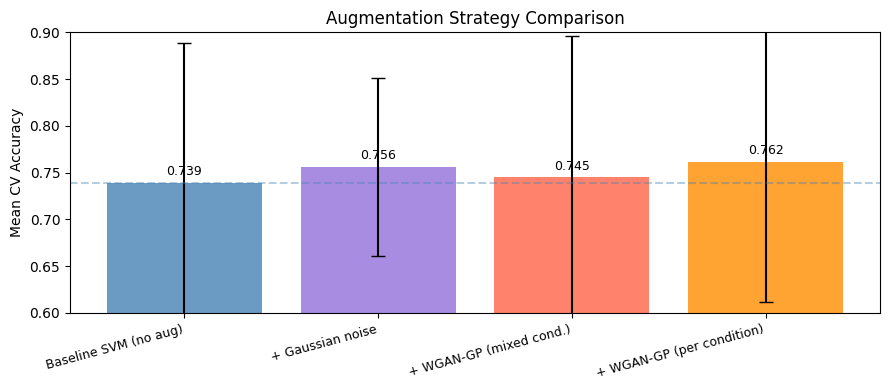

In [83]:
methods = [
    ("Baseline SVM (no aug)",      base_df["accuracy"].mean(),  base_df["f1"].mean(),  base_df["accuracy"].std()),
    ("+ Gaussian noise",           noise_df["accuracy"].mean(), noise_df["f1"].mean(), noise_df["accuracy"].std()),
    ("+ WGAN-GP (mixed cond.)",    gan_df["accuracy"].mean(),   gan_df["f1"].mean(),   gan_df["accuracy"].std()),
    ("+ WGAN-GP (per condition)",  cond_df["accuracy"].mean(),  cond_df["f1"].mean(),  cond_df["accuracy"].std()),
]

baseline_acc = base_df["accuracy"].mean()
print(f"{'Method':<35} {'Accuracy':>9} {'F1':>8} {'Std':>8} {'Δ vs Base':>10}")
print("─" * 75)
for name, acc, f1, std in methods:
    delta = acc - baseline_acc
    marker = " ◀ best" if acc == max(m[1] for m in methods) else ""
    print(f"{name:<35} {acc:>9.3f} {f1:>8.3f} {std:>8.3f} {delta:>+10.3f}{marker}")

fig, ax = plt.subplots(figsize=(9, 4))
names = [m[0] for m in methods]
accs  = [m[1] for m in methods]
stds  = [m[3] for m in methods]
colours = ['steelblue', 'mediumpurple', 'tomato', 'darkorange']

bars = ax.bar(names, accs, yerr=stds, capsize=5, color=colours, alpha=0.8)
ax.axhline(baseline_acc, linestyle='--', color='steelblue', alpha=0.4, label='Baseline')
ax.set_ylabel('Mean CV Accuracy')
ax.set_title('Augmentation Strategy Comparison')
ax.set_ylim(0.6, 0.9)
ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{acc:.3f}", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()